In [1]:
import netCDF4 as nc
import os

#base = "/Users/bernardnkrumahattobrah/Documents/HydroBlocks/data/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_Bernard"
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
cid = 1

input_file = os.path.join(path_pp, f"{cid}/input_file.nc")
output_file = os.path.join(path_pp, f"output_data/{cid}/2016-01-01.nc")

def list_nc_vars(path):
    print(f"\n--- File: {path} ---")
    with nc.Dataset(path) as ds:
        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(f"  {vname:20s} shape={var.shape} dims={var.dimensions}")

# Inspect static (parameters/meteorology)
list_nc_vars(input_file)

# Inspect dynamic outputs
list_nc_vars(output_file)



--- File: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/1/input_file.nc ---

[Group: meteorology]
  lwdown               shape=(8744, 1000) dims=('time', 'hru')
  swdown               shape=(8744, 1000) dims=('time', 'hru')
  tair                 shape=(8744, 1000) dims=('time', 'hru')
  precip               shape=(8744, 1000) dims=('time', 'hru')
  psurf                shape=(8744, 1000) dims=('time', 'hru')
  wind                 shape=(8744, 1000) dims=('time', 'hru')
  spfh                 shape=(8744, 1000) dims=('time', 'hru')
  time                 shape=(8744,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                 shape=(4,) dims=('connections_columns',)
  indices              shape=(4,) dims=('connections_columns',)
  indptr               shape=(3,) dims=('connections_rows',)

[Group: wmatrix_Basin2]
  data                 shape=(4,) dims=('connections_c

In [8]:
'''
import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
from pathlib import Path

# model outputs
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/"

# Path to run
path = path_3d

# output directory
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Polar_Plots"
os.makedirs(outputdir, exist_ok=True)

# READ TIME (FROM INPUT FILE)
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]
fp.close()

# BUILD DATETIME VECTOR
start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# Read HRU grid + metadata
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

with rasterio.open(path + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)

with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
    nhrus = ds.groups["data"].variables["totsmc"].shape[1]

def read_grid(fp):
    with rasterio.open(fp) as ds:
        arr = ds.read(1)
        nod = ds.nodata
        if nod is not None:
            arr[arr == nod] = np.nan
        arr[arr == -9999.0] = np.nan
        return arr

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

'''


In [3]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as colors

path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/"

path = path_3d

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Polar_Plots"
os.makedirs(outputdir, exist_ok=True)

buffer = 250

with nc.Dataset(path + "1/input_file.nc") as fp:
    time = fp.groups["meteorology"]["time"][:]

start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

times = pd.Series(datetime_series, name="datetime")
months = np.array(times.dt.month)

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]

    return out

import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
from pathlib import Path

# model outputs
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/"

# Path to run
path = path_3d

# output directory
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Polar_Plots"
os.makedirs(outputdir, exist_ok=True)

# READ TIME (FROM INPUT FILE)
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]
fp.close()

# BUILD DATETIME VECTOR
start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# Read HRU grid + metadata
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

with rasterio.open(path + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)

with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
    nhrus = ds.groups["data"].variables["totsmc"].shape[1]

def read_grid(fp):
    with rasterio.open(fp) as ds:
        arr = ds.read(1)
        nod = ds.nodata
        if nod is not None:
            arr[arr == nod] = np.nan
        arr[arr == -9999.0] = np.nan
        return arr

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

def crop_grid(arr, buffer):
    nrows, ncols = arr.shape
    return arr[buffer:nrows-buffer+1, buffer:ncols-buffer+1]


def load_mapping_and_terrain(path_pp, path_3d, buffer):
    hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
    cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")

    hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
    cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

    tmp_3d = np.copy(hrus_3d)
    tmp_3d[:] = -9999.0

    tmp_pp = np.copy(hrus_pp)
    tmp_pp[:] = -9999.0

    slope_grid = gdal_tools.read_raster(path_3d + "1/slope_latlon.tif")
    aspect_grid = gdal_tools.read_raster(path_3d + "1/aspect_latlon.tif")

    slope_grid = np.where(slope_grid == -9999, np.nan, slope_grid)
    aspect_grid = np.where(aspect_grid == -9999, np.nan, aspect_grid)

    slope_deg_grid = np.degrees(np.arctan(slope_grid))
    aspect_deg_grid = np.mod(np.degrees(aspect_grid), 360.0)

    slope_deg_grid = crop_grid(slope_deg_grid, buffer)
    aspect_deg_grid = crop_grid(aspect_deg_grid, buffer)

    print("same HRU grid:", np.array_equal(hrus_3d, hrus_pp))
    print("same CID grid:", np.array_equal(cids_3d, cids_pp))

    return hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid


def read_hru_vars(path, varnames):
    with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
        grp = ds.groups["data"]
        print("Variables:", list(grp.variables.keys()))

        data = {}
        for var in varnames:
            if var not in grp.variables:
                raise KeyError(f"{var} not found in output")
            data[var] = np.array(grp.variables[var][:], dtype=float)

    return data


def build_polar_from_grid_diff(
    mean_3d, mean_pp,
    hrus_3d, cids_3d, tmp_3d,
    hrus_pp, cids_pp, tmp_pp,
    slope_deg_grid, aspect_deg_grid,
    slope_edges, aspect_edges,
    buffer
):
    grid_3d = place_data(tmp_3d, mean_3d, hrus_3d, cids_3d, 1)
    grid_pp = place_data(tmp_pp, mean_pp, hrus_pp, cids_pp, 1)

    grid_3d = np.where(grid_3d == -9999, np.nan, grid_3d)
    grid_pp = np.where(grid_pp == -9999, np.nan, grid_pp)

    grid_3d = crop_grid(grid_3d, buffer)
    grid_pp = crop_grid(grid_pp, buffer)

    diff_grid = grid_3d - grid_pp

    n_r = len(slope_edges) - 1
    n_t = len(aspect_edges)

    polar_mean = np.full((n_r, n_t), np.nan)
    polar_count = np.zeros((n_r, n_t), dtype=int)

    valid = (
        np.isfinite(diff_grid) &
        np.isfinite(slope_deg_grid) &
        np.isfinite(aspect_deg_grid)
    )

    dvals = diff_grid[valid]
    svals = slope_deg_grid[valid]
    avals = aspect_deg_grid[valid]

    for i in range(n_r):
        s0, s1 = slope_edges[i], slope_edges[i + 1]
        slope_mask = (svals >= s0) & (svals < s1)

        for j in range(n_t):
            a0 = aspect_edges[j]
            a1 = a0 + 22.5

            if a1 < 360:
                aspect_mask = (avals >= a0) & (avals < a1)
            else:
                aspect_mask = (avals >= a0) | (avals < (a1 - 360))

            mask = slope_mask & aspect_mask

            if np.any(mask):
                polar_mean[i, j] = np.nanmean(dvals[mask])
                polar_count[i, j] = np.sum(mask)

    polar_mean = np.column_stack([polar_mean, polar_mean[:, 0]])
    polar_count = np.column_stack([polar_count, polar_count[:, 0]])

    return polar_mean, polar_count

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_86496/1967441969.py:138: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.mod(np.degrees(aspect_grid), 360.0)


same HRU grid: False
same CID grid: True
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_86496/3103966562.py:143: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_86496/3103966562.py:135: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


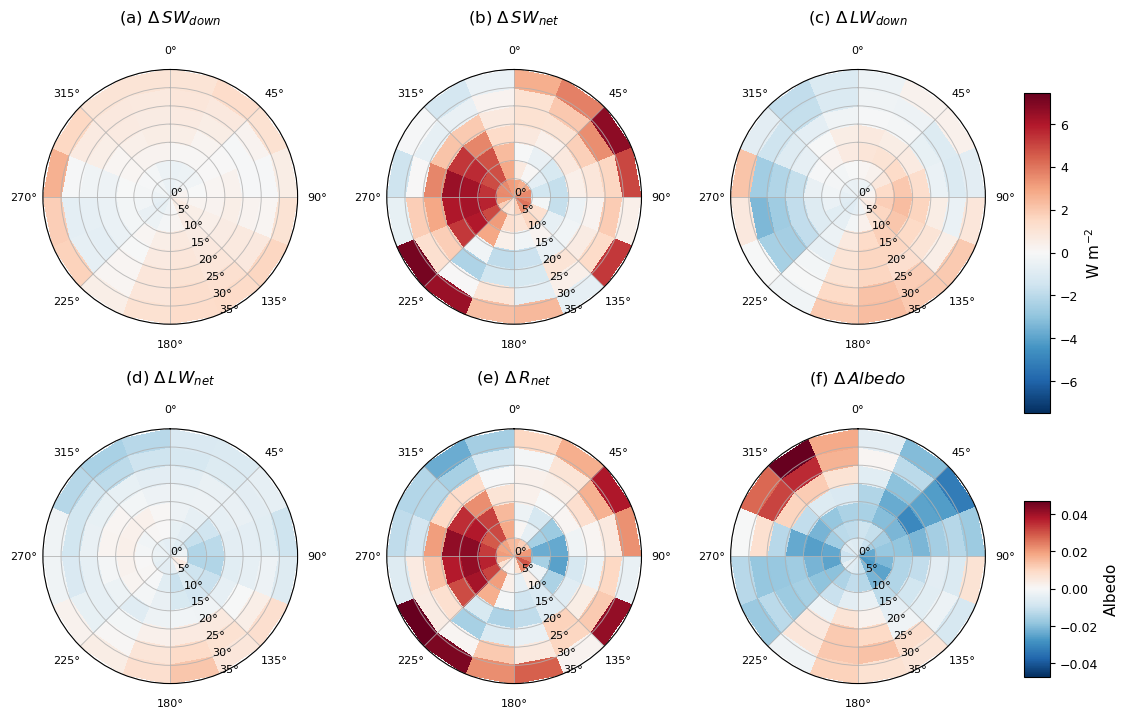

Slope range: 0.0 63.863884
Aspect range: 0.0 359.99985


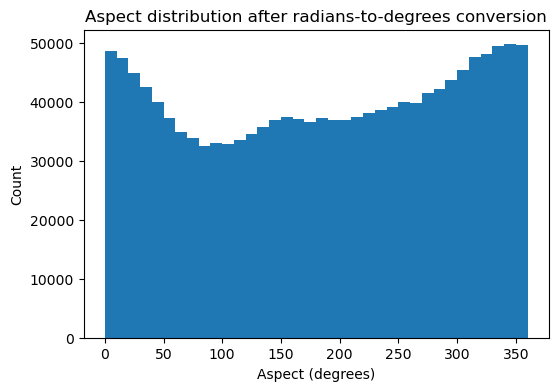


Counts per bin for ΔSWdown:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 23751 24151 23716 22817]
 [13584 12603 11333 10625 10961 11594 12757 11631 11321 11599 12956 13252
  13215 13233 13761 13614 13584]
 [ 9377  8846  7666  7160  7220  7796  8994  9092  8662  7877  7973  7672
   7977  8697  9342  9617  9377]
 [ 6216  5363  4482  4057  3886  4558  5836  6316  6173  5107  4037  3637
   3754  4405  5622  6422  6216]
 [ 3023  2443  1603  1289  1391  1947  2871  3554  3219  2319  1368  1063
    919  1359  2196  2955  3023]
 [  746   511   330   274   346   473   964  1214  1055   608   241   148
    129   253   580   777   746]]

Counts per bin for ΔSWnet:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 2375

In [4]:
# Polar plots of annual radiation + albedo differences
# Difference = 3D - PP

print("3D:", path_3d)
print("PP:", path_pp)

hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid = load_mapping_and_terrain(
    path_pp, path_3d, buffer
)

vars_needed = ["swdn", "swnet", "lwdn", "lwnet", "salb"]

data_3d = read_hru_vars(path_3d, vars_needed)
data_pp = read_hru_vars(path_pp, vars_needed)

swdn_3d  = data_3d["swdn"]
swnet_3d = data_3d["swnet"]
lwdn_3d  = data_3d["lwdn"]
lwnet_3d = data_3d["lwnet"]
salb_3d  = data_3d["salb"]

swdn_pp  = data_pp["swdn"]
swnet_pp = data_pp["swnet"]
lwdn_pp  = data_pp["lwdn"]
lwnet_pp = data_pp["lwnet"]
salb_pp  = data_pp["salb"]

# clean albedo
salb_3d = np.where((salb_3d >= 0.0) & (salb_3d <= 1.0), salb_3d, np.nan)
salb_pp = np.where((salb_pp >= 0.0) & (salb_pp <= 1.0), salb_pp, np.nan)

# net radiation
rnet_3d = swnet_3d + lwnet_3d
rnet_pp = swnet_pp + lwnet_pp

mean_3d = {
    "ΔSWdown": np.nanmean(swdn_3d,  axis=0),
    "ΔSWnet":  np.nanmean(swnet_3d, axis=0),
    "ΔLWdown": np.nanmean(lwdn_3d,  axis=0),
    "ΔLWnet":  np.nanmean(lwnet_3d, axis=0),
    "ΔRnet":   np.nanmean(rnet_3d,  axis=0),
    "ΔAlbedo": np.nanmean(salb_3d,  axis=0),
}

mean_pp = {
    "ΔSWdown": np.nanmean(swdn_pp,  axis=0),
    "ΔSWnet":  np.nanmean(swnet_pp, axis=0),
    "ΔLWdown": np.nanmean(lwdn_pp,  axis=0),
    "ΔLWnet":  np.nanmean(lwnet_pp, axis=0),
    "ΔRnet":   np.nanmean(rnet_pp,  axis=0),
    "ΔAlbedo": np.nanmean(salb_pp,  axis=0),
}

# slope/aspect bins
slope_edges = np.arange(0, 40, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
Theta, R = np.meshgrid(theta_edges, slope_edges)

panel_order = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet", "ΔAlbedo"]

polar_means = {}
polar_counts = {}

for key in panel_order:
    pm, pc = build_polar_from_grid_diff(
        mean_3d[key], mean_pp[key],
        hrus_3d, cids_3d, tmp_3d,
        hrus_pp, cids_pp, tmp_pp,
        slope_deg_grid, aspect_deg_grid,
        slope_edges, aspect_edges,
        buffer
    )

    polar_means[key] = pm
    polar_counts[key] = pc

# color scales
rad_keys = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet"]

all_rad_vals = []
for key in rad_keys:
    vals = polar_means[key]
    vals = vals[np.isfinite(vals)]
    if vals.size > 0:
        all_rad_vals.append(vals)

all_rad_vals = np.concatenate(all_rad_vals)
vmax_rad = np.nanmax(np.abs(all_rad_vals))

if not np.isfinite(vmax_rad) or vmax_rad == 0:
    vmax_rad = 1.0

alb_vals = polar_means["ΔAlbedo"]
alb_vals = alb_vals[np.isfinite(alb_vals)]
vmax_alb = np.nanmax(np.abs(alb_vals))

if not np.isfinite(vmax_alb) or vmax_alb == 0:
    vmax_alb = 0.01

norm_rad = colors.TwoSlopeNorm(vmin=-vmax_rad, vcenter=0.0, vmax=vmax_rad)
norm_alb = colors.TwoSlopeNorm(vmin=-vmax_alb, vcenter=0.0, vmax=vmax_alb)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

# plot
fig = plt.figure(figsize=(13, 8), facecolor="white")

axes = [
    fig.add_subplot(2, 3, 1, projection="polar"),
    fig.add_subplot(2, 3, 2, projection="polar"),
    fig.add_subplot(2, 3, 3, projection="polar"),
    fig.add_subplot(2, 3, 4, projection="polar"),
    fig.add_subplot(2, 3, 5, projection="polar"),
    fig.add_subplot(2, 3, 6, projection="polar"),
]

panel_titles = [
    r"(a) $\Delta\,SW_{down}$",
    r"(b) $\Delta\,SW_{net}$",
    r"(c) $\Delta\,LW_{down}$",
    r"(d) $\Delta\,LW_{net}$",
    r"(e) $\Delta\,R_{net}$",
    r"(f) $\Delta\,Albedo$",
]

pcm_rad = None
pcm_alb = None

for ax, key, title in zip(axes, panel_order, panel_titles):

    if key == "ΔAlbedo":
        pcm = ax.pcolormesh(
            Theta, R, polar_means[key],
            cmap=cmap,
            norm=norm_alb,
            shading="auto"
        )
        pcm_alb = pcm
    else:
        pcm = ax.pcolormesh(
            Theta, R, polar_means[key],
            cmap=cmap,
            norm=norm_rad,
            shading="auto"
        )
        pcm_rad = pcm

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=8)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=8
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=12, pad=16)
    ax.set_facecolor("white")

plt.subplots_adjust(wspace=0.35, hspace=0.40, right=0.85)

# radiation colorbar
cax1 = fig.add_axes([0.88, 0.45, 0.02, 0.40])
cbar1 = fig.colorbar(pcm_rad, cax=cax1)
cbar1.set_label(r"W m$^{-2}$", fontsize=11)
cbar1.ax.tick_params(labelsize=9)

# albedo colorbar
cax2 = fig.add_axes([0.88, 0.12, 0.02, 0.22])
cbar2 = fig.colorbar(pcm_alb, cax=cax2)
cbar2.set_label("Albedo", fontsize=11)
cbar2.ax.tick_params(labelsize=9)

plt.savefig(
    os.path.join(outputdir, "polar_annual_diff_radiation_albedo_gridspace_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# diagnostics
print("Slope range:", np.nanmin(slope_deg_grid), np.nanmax(slope_deg_grid))
print("Aspect range:", np.nanmin(aspect_deg_grid), np.nanmax(aspect_deg_grid))

plt.figure(figsize=(6, 4))
plt.hist(aspect_deg_grid[np.isfinite(aspect_deg_grid)].flatten(), bins=36)
plt.title("Aspect distribution after radians-to-degrees conversion")
plt.xlabel("Aspect (degrees)")
plt.ylabel("Count")
plt.show()

for key in panel_order:
    print(f"\nCounts per bin for {key}:")
    print(polar_counts[key])

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/
same HRU grid: False
same CID grid: True


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_86496/1237445147.py:42: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.mod(aspect_deg_grid, 360.0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_86496/1237445147.py:229: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_86496/1237445147.py:223: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  p

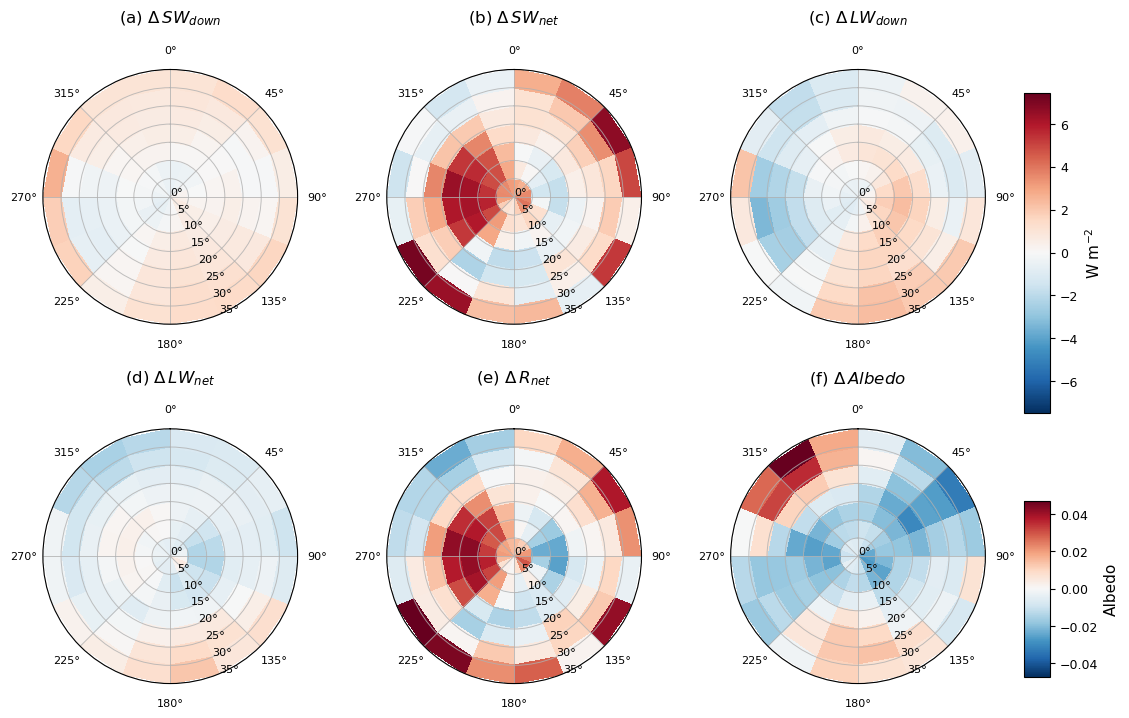

Slope range: 0.0 63.863884
Aspect range: 0.0 359.99985


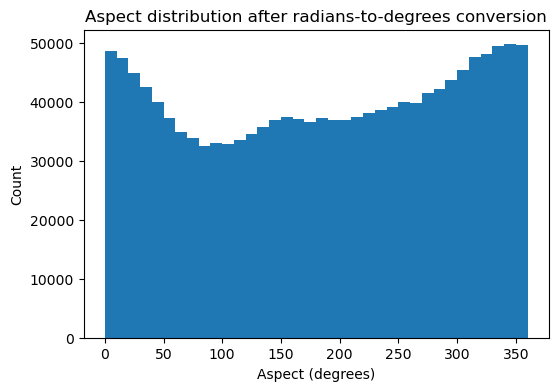


Counts per bin for ΔSWdown:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 23751 24151 23716 22817]
 [13584 12603 11333 10625 10961 11594 12757 11631 11321 11599 12956 13252
  13215 13233 13761 13614 13584]
 [ 9377  8846  7666  7160  7220  7796  8994  9092  8662  7877  7973  7672
   7977  8697  9342  9617  9377]
 [ 6216  5363  4482  4057  3886  4558  5836  6316  6173  5107  4037  3637
   3754  4405  5622  6422  6216]
 [ 3023  2443  1603  1289  1391  1947  2871  3554  3219  2319  1368  1063
    919  1359  2196  2955  3023]
 [  746   511   330   274   346   473   964  1214  1055   608   241   148
    129   253   580   777   746]]

Counts per bin for ΔSWnet:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 2375

In [2]:
# Polar plots of annual radiation + albedo differences (3D - PP)
# maps 3D to 3D grid, PP to PP grid, then subtracts in grid space
# aspect is converted from radians to degrees

import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("3D:", path_3d)
print("PP:", path_pp)

# read mapping rasters for BOTH PP and 3d
hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")

hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

tmp_3d = np.copy(hrus_3d)
tmp_3d[:] = -9999.0

tmp_pp = np.copy(hrus_pp)
tmp_pp[:] = -9999.0

print("same HRU grid:", np.array_equal(hrus_3d, hrus_pp))
print("same CID grid:", np.array_equal(cids_3d, cids_pp))

# slope and aspect from 3D grid
slope_grid = gdal_tools.read_raster(path_3d + "1/slope_latlon.tif")
aspect_grid = gdal_tools.read_raster(path_3d + "1/aspect_latlon.tif")

slope_grid = np.where(slope_grid == -9999, np.nan, slope_grid)
aspect_grid = np.where(aspect_grid == -9999, np.nan, aspect_grid)

# slope is tan(theta)
slope_deg_grid = np.degrees(np.arctan(slope_grid))

# aspect is in radians, convert to degrees
aspect_deg_grid = np.degrees(aspect_grid)
aspect_deg_grid = np.mod(aspect_deg_grid, 360.0)

# crop helper function
def crop_grid(arr, buffer):
    nrows, ncols = arr.shape
    return arr[buffer:nrows-buffer+1, buffer:ncols-buffer+1]

slope_deg_grid = crop_grid(slope_deg_grid, buffer)
aspect_deg_grid = crop_grid(aspect_deg_grid, buffer)

# read outputs
with nc.Dataset(path_3d + "output_data/1/2016-01-01.nc") as ds:
    grp = ds.groups["data"]
    swdn_3d  = np.array(grp.variables["swdn"][:])
    swnet_3d = np.array(grp.variables["swnet"][:])
    lwdn_3d  = np.array(grp.variables["lwdn"][:])
    lwnet_3d = np.array(grp.variables["lwnet"][:])
    salb_3d  = np.array(grp.variables["salb"][:])

with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as ds:
    grp = ds.groups["data"]
    swdn_pp  = np.array(grp.variables["swdn"][:])
    swnet_pp = np.array(grp.variables["swnet"][:])
    lwdn_pp  = np.array(grp.variables["lwdn"][:])
    lwnet_pp = np.array(grp.variables["lwnet"][:])
    salb_pp  = np.array(grp.variables["salb"][:])

# clean albedo
salb_3d = np.where((salb_3d >= 0.0) & (salb_3d <= 1.0), salb_3d, np.nan)
salb_pp = np.where((salb_pp >= 0.0) & (salb_pp <= 1.0), salb_pp, np.nan)

# net radiation (Not in model output and so computed)
rnet_3d = swnet_3d + lwnet_3d
rnet_pp = swnet_pp + lwnet_pp

# -------------------------------------------------
# annual mean in HRU space
# -------------------------------------------------
mean_3d = {
    "ΔSWdown": np.nanmean(swdn_3d,  axis=0),
    "ΔSWnet":  np.nanmean(swnet_3d, axis=0),
    "ΔLWdown": np.nanmean(lwdn_3d,  axis=0),
    "ΔLWnet":  np.nanmean(lwnet_3d, axis=0),
    "ΔRnet":   np.nanmean(rnet_3d,  axis=0),
    "ΔAlbedo": np.nanmean(salb_3d,  axis=0),
}

mean_pp = {
    "ΔSWdown": np.nanmean(swdn_pp,  axis=0),
    "ΔSWnet":  np.nanmean(swnet_pp, axis=0),
    "ΔLWdown": np.nanmean(lwdn_pp,  axis=0),
    "ΔLWnet":  np.nanmean(lwnet_pp, axis=0),
    "ΔRnet":   np.nanmean(rnet_pp,  axis=0),
    "ΔAlbedo": np.nanmean(salb_pp,  axis=0),
}

# slope and aspect bins
slope_edges = np.arange(0, 40, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
r_edges = slope_edges
Theta, R = np.meshgrid(theta_edges, r_edges)

# build polar means from GRID difference
def build_polar_mean_from_grid_diff(var_key):

    grid_3d = place_data(tmp_3d, mean_3d[var_key], hrus_3d, cids_3d, 1)
    grid_pp = place_data(tmp_pp, mean_pp[var_key], hrus_pp, cids_pp, 1)

    grid_3d = np.where(grid_3d == -9999, np.nan, grid_3d)
    grid_pp = np.where(grid_pp == -9999, np.nan, grid_pp)

    grid_3d = crop_grid(grid_3d, buffer)
    grid_pp = crop_grid(grid_pp, buffer)

    # Difference (model outputs)
    diff_grid = grid_3d - grid_pp

    n_r = len(slope_edges) - 1
    n_t = len(aspect_edges)

    polar_mean = np.full((n_r, n_t), np.nan)
    polar_count = np.zeros((n_r, n_t), dtype=int)

    valid = (np.isfinite(diff_grid) & np.isfinite(slope_deg_grid) & np.isfinite(aspect_deg_grid))

    dvals = diff_grid[valid]
    svals = slope_deg_grid[valid]
    avals = aspect_deg_grid[valid]

    for i in range(n_r):
        s0 = slope_edges[i]
        s1 = slope_edges[i + 1]
        slope_mask = (svals >= s0) & (svals < s1)

        for j in range(n_t):
            a0 = aspect_edges[j]
            a1 = a0 + 22.5

            if a1 < 360:
                aspect_mask = (avals >= a0) & (avals < a1)
            else:
                aspect_mask = (avals >= a0) | (avals < (a1 - 360))

            mask = slope_mask & aspect_mask

            if np.any(mask):
                polar_mean[i, j] = np.nanmean(dvals[mask])
                polar_count[i, j] = np.sum(mask)

    polar_mean = np.column_stack([polar_mean, polar_mean[:, 0]])
    polar_count = np.column_stack([polar_count, polar_count[:, 0]])

    return polar_mean, polar_count

# build polar arrays
panel_order = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet", "ΔAlbedo"]

polar_means = {}
polar_counts = {}

for key in panel_order:
    pm, pc = build_polar_mean_from_grid_diff(key)
    polar_means[key] = pm
    polar_counts[key] = pc

# color scales
rad_keys = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet"]

all_rad_vals = []
for key in rad_keys:
    vals = polar_means[key]
    vals = vals[np.isfinite(vals)]
    if vals.size > 0:
        all_rad_vals.append(vals)

all_rad_vals = np.concatenate(all_rad_vals)
vmax_rad = np.nanmax(np.abs(all_rad_vals))
if not np.isfinite(vmax_rad) or vmax_rad == 0:
    vmax_rad = 1.0

alb_vals = polar_means["ΔAlbedo"]
alb_vals = alb_vals[np.isfinite(alb_vals)]
vmax_alb = np.nanmax(np.abs(alb_vals))
if not np.isfinite(vmax_alb) or vmax_alb == 0:
    vmax_alb = 0.01

norm_rad = colors.TwoSlopeNorm(vmin=-vmax_rad, vcenter=0.0, vmax=vmax_rad)
norm_alb = colors.TwoSlopeNorm(vmin=-vmax_alb, vcenter=0.0, vmax=vmax_alb)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

# plot
fig = plt.figure(figsize=(13, 8), facecolor="white")

axes = [
    fig.add_subplot(2, 3, 1, projection="polar"),
    fig.add_subplot(2, 3, 2, projection="polar"),
    fig.add_subplot(2, 3, 3, projection="polar"),
    fig.add_subplot(2, 3, 4, projection="polar"),
    fig.add_subplot(2, 3, 5, projection="polar"),
    fig.add_subplot(2, 3, 6, projection="polar"),
]

panel_titles = [
    r"(a) $\Delta\,SW_{down}$",
    r"(b) $\Delta\,SW_{net}$",
    r"(c) $\Delta\,LW_{down}$",
    r"(d) $\Delta\,LW_{net}$",
    r"(e) $\Delta\,R_{net}$",
    r"(f) $\Delta\,Albedo$",
]

pcm_rad = None
pcm_alb = None

for ax, key, title in zip(axes, panel_order, panel_titles):

    if key == "ΔAlbedo":
        pcm = ax.pcolormesh(
            Theta, R, polar_means[key],
            cmap=cmap, norm=norm_alb, shading="flat"
        )
        pcm_alb = pcm
    else:
        pcm = ax.pcolormesh(
            Theta, R, polar_means[key],
            cmap=cmap, norm=norm_rad, shading="auto"
        )
        pcm_rad = pcm

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=8)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=8
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=12, pad=16)
    ax.set_facecolor("white")

plt.subplots_adjust(wspace=0.35, hspace=0.40, right=0.85)

# radiation colorbar
cax1 = fig.add_axes([0.88, 0.45, 0.02, 0.40])
cbar1 = fig.colorbar(pcm_rad, cax=cax1)
cbar1.set_label(r"W m$^{-2}$", fontsize=11)
cbar1.ax.tick_params(labelsize=9)

# albedo colorbar
cax2 = fig.add_axes([0.88, 0.12, 0.02, 0.22])
cbar2 = fig.colorbar(pcm_alb, cax=cax2)
cbar2.set_label("Albedo", fontsize=11)
cbar2.ax.tick_params(labelsize=9)

plt.savefig(
    os.path.join(outputdir, "polar_annual_diff_radiation_albedo_gridspace_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# diagnostics
print("Slope range:", np.nanmin(slope_deg_grid), np.nanmax(slope_deg_grid))
print("Aspect range:", np.nanmin(aspect_deg_grid), np.nanmax(aspect_deg_grid))

plt.figure(figsize=(6, 4))
plt.hist(aspect_deg_grid[np.isfinite(aspect_deg_grid)].flatten(), bins=36)
plt.title("Aspect distribution after radians-to-degrees conversion")
plt.xlabel("Aspect (degrees)")
plt.ylabel("Count")
plt.show()

for key in panel_order:
    print(f"\nCounts per bin for {key}:")
    print(polar_counts[key])



# Comments:
# Hao paper-style figure uses slope bins from 0–35° at 5° intervals,
# following the published polar-plot approach. This keeps all slope-aspect
# bins well populated and avoids sparse high-slope bins or pathy map output.

In [25]:
threshold = 200

for key in panel_order:
    print(f"\nLow-count bins for {key} (<{threshold} cells):")

    pc = polar_counts[key][:, :-1]   # remove duplicated last column

    for i in range(pc.shape[0]):       # slope bins
        for j in range(pc.shape[1]):   # aspect bins
            if pc[i, j] < threshold:
                
                s0 = slope_edges[i]
                s1 = slope_edges[i+1]

                a0 = aspect_edges[j]
                a1 = a0 + 22.5

                print(f"  Slope {s0:>2}-{s1:<2}°, Aspect {a0:>5.1f}-{a1:<5.1f}°, Count={pc[i,j]}")


Low-count bins for ΔSWdown (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔSWnet (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔLWdown (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔLWnet (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔRnet (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔAlbedo (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129


In [26]:
threshold = 200

for key in panel_order:
    pc = polar_counts[key][:, :-1]

    total_bins = pc.size
    low_bins = np.sum(pc < threshold)

    print(f"\n{key}:")
    print(f"  Total bins: {total_bins}")
    print(f"  Bins < {threshold}: {low_bins} ({100*low_bins/total_bins:.2f}%)")


ΔSWdown:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔSWnet:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔLWdown:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔLWnet:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔRnet:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔAlbedo:
  Total bins: 112
  Bins < 200: 2 (1.79%)


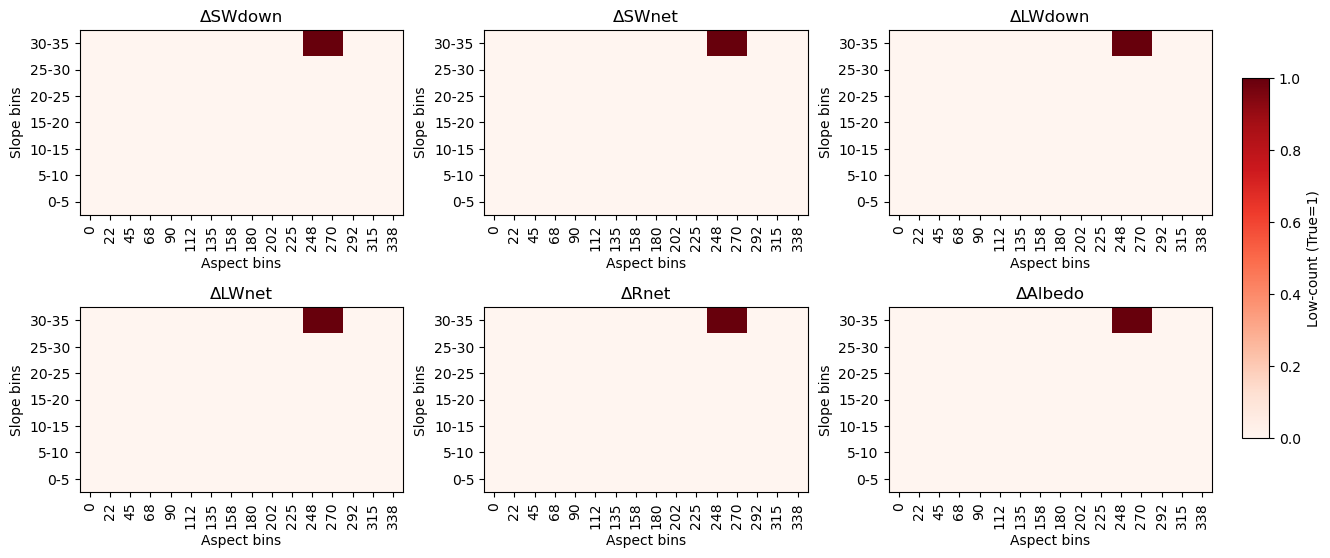

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()

for i, key in enumerate(panel_order):
    ax = axes[i]

    pc = polar_counts[key][:, :-1]
    low_mask = pc < 200

    im = ax.imshow(low_mask, cmap="Reds", origin="lower", aspect="auto")

    ax.set_title(f"{key}")
    ax.set_xlabel("Aspect bins")
    ax.set_ylabel("Slope bins")

    ax.set_xticks(range(len(aspect_edges)))
    ax.set_xticklabels([f"{a:.0f}" for a in aspect_edges], rotation=90)

    ax.set_yticks(range(len(slope_edges)-1))
    ax.set_yticklabels([f"{slope_edges[i]}-{slope_edges[i+1]}" for i in range(len(slope_edges)-1)])

# manually tighten panels and leave room for colorbar
plt.subplots_adjust(hspace=0.50, wspace=0.25, right=0.88)

# colorbar outside right
cbar_ax = fig.add_axes([0.90, 0.20, 0.018, 0.60])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Low-count (True=1)")

plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/
same HRU grid: False
same CID grid: True


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_501253/1624570576.py:46: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.mod(aspect_deg_grid, 360.0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_501253/1624570576.py:253: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_501253/1624570576.py:247: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


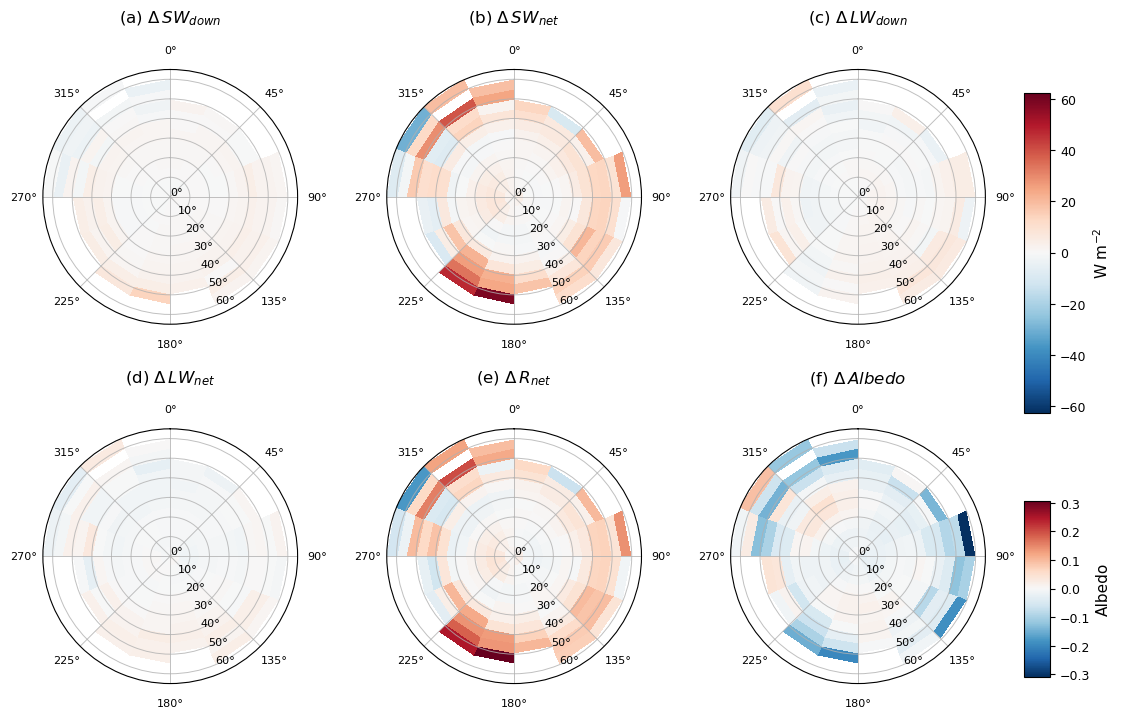

Slope range: 0.0 63.863884
Aspect range: 0.0 359.99985


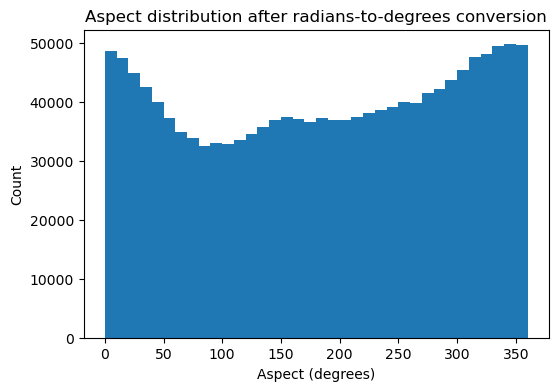


Counts per bin for ΔSWdown:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 23751 24151 23716 22817]
 [13584 12603 11333 10625 10961 11594 12757 11631 11321 11599 12956 13252
  13215 13233 13761 13614 13584]
 [ 9377  8846  7666  7160  7220  7796  8994  9092  8662  7877  7973  7672
   7977  8697  9342  9617  9377]
 [ 6216  5363  4482  4057  3886  4558  5836  6316  6173  5107  4037  3637
   3754  4405  5622  6422  6216]
 [ 3023  2443  1603  1289  1391  1947  2871  3554  3219  2319  1368  1063
    919  1359  2196  2955  3023]
 [  746   511   330   274   346   473   964  1214  1055   608   241   148
    129   253   580   777   746]
 [  135   124   101    60    72   126   233   291   239   196    85    51
     19    47   100   174   135]
 [   29    27    46    26    16    22    54   107    71    66    15    10
      6     4    21    24    29]
 [    5 

In [59]:
# Polar plots of annual radiation + albedo differences (3D - PP)
# maps 3D to 3D grid, PP to PP grid, then subtracts in grid space
# aspect is converted from radians to degrees

print("3D:", path_3d)
print("PP:", path_pp)

# -------------------------------------------------
# read mapping rasters for BOTH runs
# -------------------------------------------------
hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")

hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

tmp_3d = np.copy(hrus_3d)
tmp_3d[:] = -9999.0

tmp_pp = np.copy(hrus_pp)
tmp_pp[:] = -9999.0

print("same HRU grid:", np.array_equal(hrus_3d, hrus_pp))
print("same CID grid:", np.array_equal(cids_3d, cids_pp))

# -------------------------------------------------
# slope and aspect from 3D grid
# -------------------------------------------------
slope_grid = gdal_tools.read_raster(path_3d + "1/slope_latlon.tif")
aspect_grid = gdal_tools.read_raster(path_3d + "1/aspect_latlon.tif")

slope_grid = np.where(slope_grid == -9999, np.nan, slope_grid)
aspect_grid = np.where(aspect_grid == -9999, np.nan, aspect_grid)

# slope is tan(theta)
slope_deg_grid = np.degrees(np.arctan(slope_grid))

# aspect is in radians, convert to degrees
aspect_deg_grid = np.degrees(aspect_grid)
aspect_deg_grid = np.mod(aspect_deg_grid, 360.0)

# -------------------------------------------------
# crop helper
# -------------------------------------------------
def crop_grid(arr, buffer):
    nrows, ncols = arr.shape
    return arr[buffer:nrows-buffer+1, buffer:ncols-buffer+1]

slope_deg_grid = crop_grid(slope_deg_grid, buffer)
aspect_deg_grid = crop_grid(aspect_deg_grid, buffer)

# -------------------------------------------------
# read outputs
# -------------------------------------------------
with nc.Dataset(path_3d + "output_data/1/2016-01-01.nc") as ds:
    grp = ds.groups["data"]
    swdn_3d  = np.array(grp.variables["swdn"][:],  dtype=float)
    swnet_3d = np.array(grp.variables["swnet"][:], dtype=float)
    lwdn_3d  = np.array(grp.variables["lwdn"][:],  dtype=float)
    lwnet_3d = np.array(grp.variables["lwnet"][:], dtype=float)
    salb_3d  = np.array(grp.variables["salb"][:],  dtype=float)

with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as ds:
    grp = ds.groups["data"]
    swdn_pp  = np.array(grp.variables["swdn"][:],  dtype=float)
    swnet_pp = np.array(grp.variables["swnet"][:], dtype=float)
    lwdn_pp  = np.array(grp.variables["lwdn"][:],  dtype=float)
    lwnet_pp = np.array(grp.variables["lwnet"][:], dtype=float)
    salb_pp  = np.array(grp.variables["salb"][:],  dtype=float)

# clean albedo
salb_3d = np.where((salb_3d >= 0.0) & (salb_3d <= 1.0), salb_3d, np.nan)
salb_pp = np.where((salb_pp >= 0.0) & (salb_pp <= 1.0), salb_pp, np.nan)

# net radiation
rnet_3d = swnet_3d + lwnet_3d
rnet_pp = swnet_pp + lwnet_pp

# -------------------------------------------------
# annual mean in HRU space
# -------------------------------------------------
mean_3d = {
    "ΔSWdown": np.nanmean(swdn_3d,  axis=0),
    "ΔSWnet":  np.nanmean(swnet_3d, axis=0),
    "ΔLWdown": np.nanmean(lwdn_3d,  axis=0),
    "ΔLWnet":  np.nanmean(lwnet_3d, axis=0),
    "ΔRnet":   np.nanmean(rnet_3d,  axis=0),
    "ΔAlbedo": np.nanmean(salb_3d,  axis=0),
}

mean_pp = {
    "ΔSWdown": np.nanmean(swdn_pp,  axis=0),
    "ΔSWnet":  np.nanmean(swnet_pp, axis=0),
    "ΔLWdown": np.nanmean(lwdn_pp,  axis=0),
    "ΔLWnet":  np.nanmean(lwnet_pp, axis=0),
    "ΔRnet":   np.nanmean(rnet_pp,  axis=0),
    "ΔAlbedo": np.nanmean(salb_pp,  axis=0),
}

# -------------------------------------------------
# bins
# -------------------------------------------------
slope_edges = np.arange(0, 70, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
r_edges = slope_edges
Theta, R = np.meshgrid(theta_edges, r_edges)

# -------------------------------------------------
# build polar means from GRID difference
# -------------------------------------------------
def build_polar_mean_from_grid_diff(var_key):

    grid_3d = place_data(tmp_3d, mean_3d[var_key], hrus_3d, cids_3d, 1)
    grid_pp = place_data(tmp_pp, mean_pp[var_key], hrus_pp, cids_pp, 1)

    grid_3d = np.where(grid_3d == -9999, np.nan, grid_3d)
    grid_pp = np.where(grid_pp == -9999, np.nan, grid_pp)

    grid_3d = crop_grid(grid_3d, buffer)
    grid_pp = crop_grid(grid_pp, buffer)

    diff_grid = grid_3d - grid_pp

    n_r = len(slope_edges) - 1
    n_t = len(aspect_edges)

    polar_mean = np.full((n_r, n_t), np.nan)
    polar_count = np.zeros((n_r, n_t), dtype=int)

    valid = (
        np.isfinite(diff_grid) &
        np.isfinite(slope_deg_grid) &
        np.isfinite(aspect_deg_grid)
    )

    dvals = diff_grid[valid]
    svals = slope_deg_grid[valid]
    avals = aspect_deg_grid[valid]

    for i in range(n_r):
        s0 = slope_edges[i]
        s1 = slope_edges[i + 1]
        slope_mask = (svals >= s0) & (svals < s1)

        for j in range(n_t):
            a0 = aspect_edges[j]
            a1 = a0 + 22.5

            if a1 < 360:
                aspect_mask = (avals >= a0) & (avals < a1)
            else:
                aspect_mask = (avals >= a0) | (avals < (a1 - 360))

            mask = slope_mask & aspect_mask

            if np.any(mask):
                polar_mean[i, j] = np.nanmean(dvals[mask])
                polar_count[i, j] = np.sum(mask)
            
    # Mask low-sample bins
    #polar_mean[polar_count < 200] = np.nan

    polar_mean = np.column_stack([polar_mean, polar_mean[:, 0]])
    polar_count = np.column_stack([polar_count, polar_count[:, 0]])

    return polar_mean, polar_count

# -------------------------------------------------
# build polar arrays
# -------------------------------------------------
panel_order = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet", "ΔAlbedo"]

polar_means = {}
polar_counts = {}

for key in panel_order:
    pm, pc = build_polar_mean_from_grid_diff(key)
    polar_means[key] = pm
    polar_counts[key] = pc

# -------------------------------------------------
# color scales
# -------------------------------------------------
rad_keys = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet"]

all_rad_vals = []
for key in rad_keys:
    vals = polar_means[key]
    vals = vals[np.isfinite(vals)]
    if vals.size > 0:
        all_rad_vals.append(vals)

all_rad_vals = np.concatenate(all_rad_vals)
vmax_rad = np.nanmax(np.abs(all_rad_vals))
if not np.isfinite(vmax_rad) or vmax_rad == 0:
    vmax_rad = 1.0

alb_vals = polar_means["ΔAlbedo"]
alb_vals = alb_vals[np.isfinite(alb_vals)]
vmax_alb = np.nanmax(np.abs(alb_vals))
if not np.isfinite(vmax_alb) or vmax_alb == 0:
    vmax_alb = 0.01

norm_rad = colors.TwoSlopeNorm(vmin=-vmax_rad, vcenter=0.0, vmax=vmax_rad)
norm_alb = colors.TwoSlopeNorm(vmin=-vmax_alb, vcenter=0.0, vmax=vmax_alb)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

# -------------------------------------------------
# plot
# -------------------------------------------------
fig = plt.figure(figsize=(13, 8), facecolor="white")

axes = [
    fig.add_subplot(2, 3, 1, projection="polar"),
    fig.add_subplot(2, 3, 2, projection="polar"),
    fig.add_subplot(2, 3, 3, projection="polar"),
    fig.add_subplot(2, 3, 4, projection="polar"),
    fig.add_subplot(2, 3, 5, projection="polar"),
    fig.add_subplot(2, 3, 6, projection="polar"),
]

panel_titles = [
    r"(a) $\Delta\,SW_{down}$",
    r"(b) $\Delta\,SW_{net}$",
    r"(c) $\Delta\,LW_{down}$",
    r"(d) $\Delta\,LW_{net}$",
    r"(e) $\Delta\,R_{net}$",
    r"(f) $\Delta\,Albedo$",
]

pcm_rad = None
pcm_alb = None

for ax, key, title in zip(axes, panel_order, panel_titles):

    if key == "ΔAlbedo":
        pcm = ax.pcolormesh(
            Theta, R, polar_means[key],
            cmap=cmap, norm=norm_alb, shading="flat"
        )
        pcm_alb = pcm
    else:
        pcm = ax.pcolormesh(
            Theta, R, polar_means[key],
            cmap=cmap, norm=norm_rad, shading="flat"
        )
        pcm_rad = pcm

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 65)
    ax.set_rticks(np.arange(0, 66, 10))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 66, 10)], fontsize=8)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=8
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=12, pad=16)
    ax.set_facecolor("white")

plt.subplots_adjust(wspace=0.35, hspace=0.40, right=0.85)

# radiation colorbar
cax1 = fig.add_axes([0.88, 0.45, 0.02, 0.40])
cbar1 = fig.colorbar(pcm_rad, cax=cax1)
cbar1.set_label(r"W m$^{-2}$", fontsize=11)
cbar1.ax.tick_params(labelsize=9)

# albedo colorbar
cax2 = fig.add_axes([0.88, 0.12, 0.02, 0.22])
cbar2 = fig.colorbar(pcm_alb, cax=cax2)
cbar2.set_label("Albedo", fontsize=11)
cbar2.ax.tick_params(labelsize=9)

plt.savefig(
    os.path.join(outputdir, "polar_annual_diff_radiation_albedo_gridspace_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# -------------------------------------------------
# diagnostics
# -------------------------------------------------
print("Slope range:", np.nanmin(slope_deg_grid), np.nanmax(slope_deg_grid))
print("Aspect range:", np.nanmin(aspect_deg_grid), np.nanmax(aspect_deg_grid))

plt.figure(figsize=(6, 4))
plt.hist(aspect_deg_grid[np.isfinite(aspect_deg_grid)].flatten(), bins=36)
plt.title("Aspect distribution after radians-to-degrees conversion")
plt.xlabel("Aspect (degrees)")
plt.ylabel("Count")
plt.show()

for key in panel_order:
    print(f"\nCounts per bin for {key}:")
    print(polar_counts[key])

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/
same HRU grid: False
same CID grid: True


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1187077/2166654557.py:41: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.mod(aspect_deg_grid, 360.0)


3D variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
PP variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1187077/2166654557.py:233: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


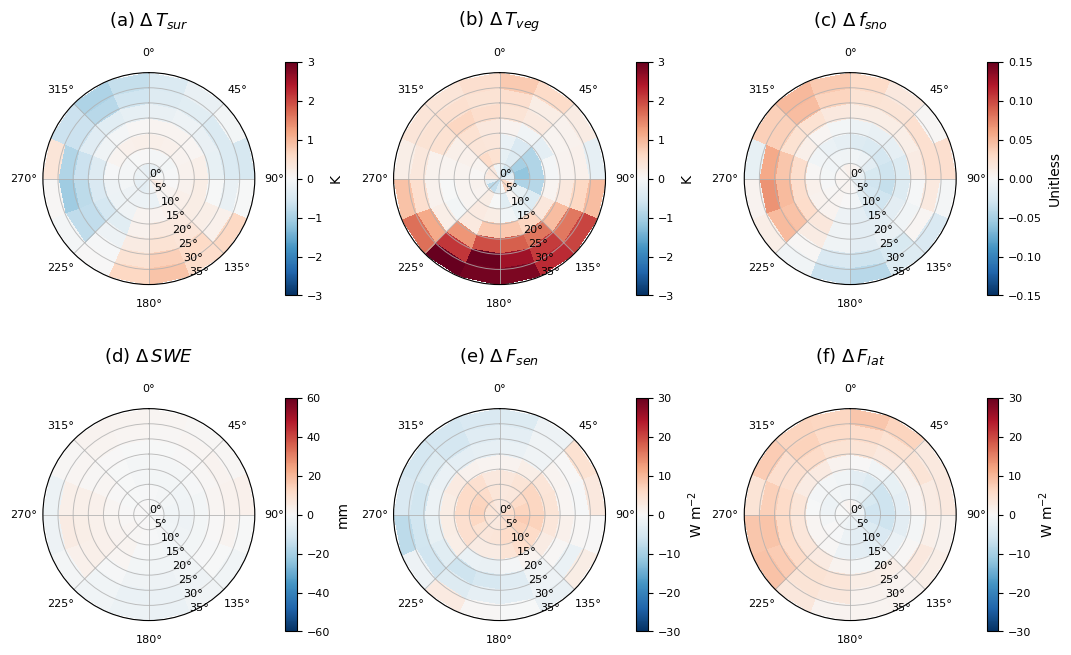

Slope range: 0.0 63.863884
Aspect range: 0.0 359.99985
ΔTsur: polar min=-1.0553, max=0.8656, mean=-0.0981

Counts per bin for ΔTsur:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 23751 24151 23716 22817]
 [13584 12603 11333 10625 10961 11594 12757 11631 11321 11599 12956 13252
  13215 13233 13761 13614 13584]
 [ 9377  8846  7666  7160  7220  7796  8994  9092  8662  7877  7973  7672
   7977  8697  9342  9617  9377]
 [ 6216  5363  4482  4057  3886  4558  5836  6316  6173  5107  4037  3637
   3754  4405  5622  6422  6216]
 [ 3023  2443  1603  1289  1391  1947  2871  3554  3219  2319  1368  1063
    919  1359  2196  2955  3023]
 [  746   511   330   274   346   473   964  1214  1055   608   241   148
    129   253   580   777   746]]
ΔTveg: polar min=-1.1895, max=3.1028, mean=0.3703

Counts per bin for ΔTveg:
[[50646 45297 38923 33820 32572 31602 32

In [21]:
# Polar plots:
# ΔTveg, ΔTsur, ΔFsen, ΔFlat, Δfsno, ΔSWE
# Difference = 3D - PP
# radius = slope, angle = aspect

print("3D:", path_3d)
print("PP:", path_pp)

# -------------------------------------------------
# read mapping rasters for BOTH runs
# -------------------------------------------------
hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")

hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

tmp_3d = np.copy(hrus_3d)
tmp_3d[:] = -9999.0

tmp_pp = np.copy(hrus_pp)
tmp_pp[:] = -9999.0

print("same HRU grid:", np.array_equal(hrus_3d, hrus_pp))
print("same CID grid:", np.array_equal(cids_3d, cids_pp))

# -------------------------------------------------
# slope and aspect from 3D grid
# -------------------------------------------------
slope_grid = gdal_tools.read_raster(path_3d + "1/slope_latlon.tif")
aspect_grid = gdal_tools.read_raster(path_3d + "1/aspect_latlon.tif")

slope_grid = np.where(slope_grid == -9999, np.nan, slope_grid)
aspect_grid = np.where(aspect_grid == -9999, np.nan, aspect_grid)

# slope is tan(theta)
slope_deg_grid = np.degrees(np.arctan(slope_grid))

# aspect is radians, convert to degrees
aspect_deg_grid = np.degrees(aspect_grid)
aspect_deg_grid = np.mod(aspect_deg_grid, 360.0)

# -------------------------------------------------
# crop helper
# -------------------------------------------------
def crop_grid(arr, buffer):
    nrows, ncols = arr.shape
    return arr[buffer:nrows-buffer+1, buffer:ncols-buffer+1]

slope_deg_grid = crop_grid(slope_deg_grid, buffer)
aspect_deg_grid = crop_grid(aspect_deg_grid, buffer)

# -------------------------------------------------
# read outputs
# -------------------------------------------------
with nc.Dataset(path_3d + "output_data/1/2016-01-01.nc") as ds:
    grp = ds.groups["data"]
    print("3D variables:", list(grp.variables.keys()))

    tv_3d    = np.array(grp.variables["tv"][:],    dtype=float)   # canopy/vegetation temp, K
    trad_3d  = np.array(grp.variables["trad"][:],  dtype=float)   # surface skin temp, K
    sh_3d    = np.array(grp.variables["sh"][:],    dtype=float)   # sensible heat, W/m2
    lh_3d    = np.array(grp.variables["lh"][:],    dtype=float)   # latent heat, W/m2
    fsno_3d  = np.array(grp.variables["fsno"][:],  dtype=float)   # snow cover fraction
    swe_3d   = np.array(grp.variables["swe"][:],   dtype=float)   # SWE, mm

with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as ds:
    grp = ds.groups["data"]
    print("PP variables:", list(grp.variables.keys()))

    tv_pp    = np.array(grp.variables["tv"][:],    dtype=float)
    trad_pp  = np.array(grp.variables["trad"][:],  dtype=float)
    sh_pp    = np.array(grp.variables["sh"][:],    dtype=float)
    lh_pp    = np.array(grp.variables["lh"][:],    dtype=float)
    fsno_pp  = np.array(grp.variables["fsno"][:],  dtype=float)
    swe_pp   = np.array(grp.variables["swe"][:],   dtype=float)

# -------------------------------------------------
# annual mean in HRU space
# -------------------------------------------------
mean_3d = {
    "ΔTveg": np.nanmean(tv_3d,   axis=0),
    "ΔTsur": np.nanmean(trad_3d, axis=0),
    "ΔFsen": np.nanmean(sh_3d,   axis=0),
    "ΔFlat": np.nanmean(lh_3d,   axis=0),
    "Δfsno": np.nanmean(fsno_3d, axis=0),
    "ΔSWE":  np.nanmean(swe_3d,  axis=0),
}

mean_pp = {
    "ΔTveg": np.nanmean(tv_pp,   axis=0),
    "ΔTsur": np.nanmean(trad_pp, axis=0),
    "ΔFsen": np.nanmean(sh_pp,   axis=0),
    "ΔFlat": np.nanmean(lh_pp,   axis=0),
    "Δfsno": np.nanmean(fsno_pp, axis=0),
    "ΔSWE":  np.nanmean(swe_pp,  axis=0),
}

# -------------------------------------------------
# bins like paper
# -------------------------------------------------
slope_edges = np.arange(0, 40, 5)        # 0–35 degrees
aspect_edges = np.arange(0, 360, 22.5)  # 16 aspect bins

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
r_edges = slope_edges
Theta, R = np.meshgrid(theta_edges, r_edges)

# -------------------------------------------------
# build polar means from GRID difference
# -------------------------------------------------
def build_polar_mean_from_grid_diff(var_key):

    grid_3d = place_data(tmp_3d, mean_3d[var_key], hrus_3d, cids_3d, 1)
    grid_pp = place_data(tmp_pp, mean_pp[var_key], hrus_pp, cids_pp, 1)

    grid_3d = np.where(grid_3d == -9999, np.nan, grid_3d)
    grid_pp = np.where(grid_pp == -9999, np.nan, grid_pp)

    grid_3d = crop_grid(grid_3d, buffer)
    grid_pp = crop_grid(grid_pp, buffer)

    diff_grid = grid_3d - grid_pp

    n_r = len(slope_edges) - 1
    n_t = len(aspect_edges)

    polar_mean = np.full((n_r, n_t), np.nan)
    polar_count = np.zeros((n_r, n_t), dtype=int)

    valid = (
        np.isfinite(diff_grid) &
        np.isfinite(slope_deg_grid) &
        np.isfinite(aspect_deg_grid)
    )

    dvals = diff_grid[valid]
    svals = slope_deg_grid[valid]
    avals = aspect_deg_grid[valid]

    for i in range(n_r):
        s0 = slope_edges[i]
        s1 = slope_edges[i + 1]
        slope_mask = (svals >= s0) & (svals < s1)

        for j in range(n_t):
            a0 = aspect_edges[j]
            a1 = a0 + 22.5

            if a1 < 360:
                aspect_mask = (avals >= a0) & (avals < a1)
            else:
                aspect_mask = (avals >= a0) | (avals < (a1 - 360))

            mask = slope_mask & aspect_mask

            if np.any(mask):
                polar_mean[i, j] = np.nanmean(dvals[mask])
                polar_count[i, j] = np.sum(mask)

    # close circle
    polar_mean = np.column_stack([polar_mean, polar_mean[:, 0]])
    polar_count = np.column_stack([polar_count, polar_count[:, 0]])

    return polar_mean, polar_count

# -------------------------------------------------
# build polar arrays
# -------------------------------------------------
panel_order = ["ΔTveg", "ΔTsur", "ΔFsen", "ΔFlat", "Δfsno", "ΔSWE"]

polar_means = {}
polar_counts = {}

for key in panel_order:
    pm, pc = build_polar_mean_from_grid_diff(key)
    polar_means[key] = pm
    polar_counts[key] = pc

# -------------------------------------------------
# color scales by variable group
# -------------------------------------------------
norms = {
    "ΔTveg": colors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3),
    "ΔTsur": colors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3),
    "ΔFsen": colors.TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30),
    "ΔFlat": colors.TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30),
    "Δfsno": colors.TwoSlopeNorm(vmin=-0.15, vcenter=0, vmax=0.15),
    "ΔSWE":  colors.TwoSlopeNorm(vmin=-60, vcenter=0, vmax=60),
}

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

# -------------------------------------------------
# plot
# -------------------------------------------------
fig = plt.figure(figsize=(13, 8), facecolor="white")

axes = [
    fig.add_subplot(2, 3, 1, projection="polar"),
    fig.add_subplot(2, 3, 2, projection="polar"),
    fig.add_subplot(2, 3, 3, projection="polar"),
    fig.add_subplot(2, 3, 4, projection="polar"),
    fig.add_subplot(2, 3, 5, projection="polar"),
    fig.add_subplot(2, 3, 6, projection="polar"),
]

panel_order = ["ΔTsur", "ΔTveg", "Δfsno", "ΔSWE", "ΔFsen", "ΔFlat"]

panel_titles = [
    r"(a) $\Delta\,T_{sur}$",
    r"(b) $\Delta\,T_{veg}$",
    r"(c) $\Delta\,f_{sno}$",
    r"(d) $\Delta\,SWE$",
    r"(e) $\Delta\,F_{sen}$",
    r"(f) $\Delta\,F_{lat}$",
]

units = {
    "ΔTveg": "K",
    "ΔTsur": "K",
    "ΔFsen": r"W m$^{-2}$",
    "ΔFlat": r"W m$^{-2}$",
    "Δfsno": "Unitless",
    "ΔSWE": "mm",
}

pcms = {}

for ax, key, title in zip(axes, panel_order, panel_titles):

    pcm = ax.pcolormesh(
        Theta,
        R,
        polar_means[key],
        cmap=cmap,
        norm=norms[key],
        shading="auto"
    )

    pcms[key] = pcm

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=8)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=8
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=13, pad=16)
    ax.set_facecolor("white")

plt.subplots_adjust(wspace=0.38, hspace=0.20, right=0.86)

# -------------------------------------------------
# individual colorbars beside each panel, paper-like
# -------------------------------------------------
for ax, key in zip(axes, panel_order):
    cbar = fig.colorbar(pcms[key], ax=ax, fraction=0.046, pad=0.12)
    cbar.set_label(units[key], fontsize=10)
    cbar.ax.tick_params(labelsize=8)

plt.savefig(
    os.path.join(outputdir, "polar_annual_diff_temp_flux_snow_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# -------------------------------------------------
# diagnostics
# -------------------------------------------------
print("Slope range:", np.nanmin(slope_deg_grid), np.nanmax(slope_deg_grid))
print("Aspect range:", np.nanmin(aspect_deg_grid), np.nanmax(aspect_deg_grid))

for key in panel_order:
    vals = polar_means[key]
    vals = vals[np.isfinite(vals)]
    print(f"{key}: polar min={np.nanmin(vals):.4f}, max={np.nanmax(vals):.4f}, mean={np.nanmean(vals):.4f}")

    print(f"\nCounts per bin for {key}:")
    print(polar_counts[key])

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1187077/2517917925.py:43: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.mod(aspect_deg_grid, 360.0)


Processing: Winter
Processing: Spring
Processing: Summer
Processing: Fall
Processing: Annual


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1187077/2517917925.py:201: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


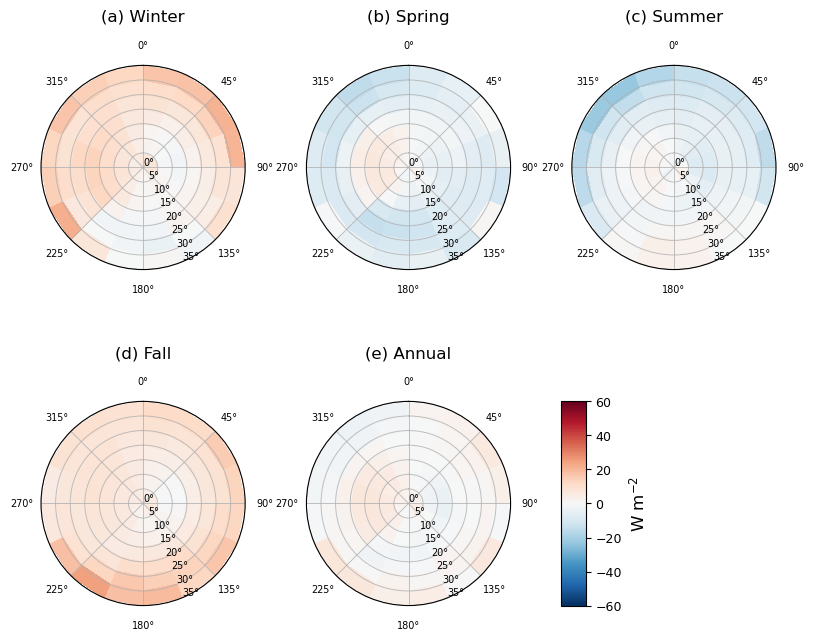

Slope range: 0.0 63.863884
Aspect range: 0.0 359.99985
Winter: min=-4.084, max=21.953, mean=6.073

Counts per bin for Winter:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 23751 24151 23716 22817]
 [13584 12603 11333 10625 10961 11594 12757 11631 11321 11599 12956 13252
  13215 13233 13761 13614 13584]
 [ 9377  8846  7666  7160  7220  7796  8994  9092  8662  7877  7973  7672
   7977  8697  9342  9617  9377]
 [ 6216  5363  4482  4057  3886  4558  5836  6316  6173  5107  4037  3637
   3754  4405  5622  6422  6216]
 [ 3023  2443  1603  1289  1391  1947  2871  3554  3219  2319  1368  1063
    919  1359  2196  2955  3023]
 [  746   511   330   274   346   473   964  1214  1055   608   241   148
    129   253   580   777   746]]
Spring: min=-15.208, max=6.601, mean=-3.616

Counts per bin for Spring:
[[50646 45297 38923 33820 32572 31602 32006 32254 35

In [27]:
# Seasonal + annual polar plots for ΔRnet (3D - PP)
# radius = slope, angle = aspect
# panels: Winter, Spring, Summer, Fall, Annual

import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("3D:", path_3d)
print("PP:", path_pp)

# -------------------------------------------------
# read mapping rasters
# -------------------------------------------------
hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")

hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

tmp_3d = np.copy(hrus_3d)
tmp_3d[:] = -9999.0

tmp_pp = np.copy(hrus_pp)
tmp_pp[:] = -9999.0

# -------------------------------------------------
# slope and aspect
# -------------------------------------------------
slope_grid = gdal_tools.read_raster(path_3d + "1/slope_latlon.tif")
aspect_grid = gdal_tools.read_raster(path_3d + "1/aspect_latlon.tif")

slope_grid = np.where(slope_grid == -9999, np.nan, slope_grid)
aspect_grid = np.where(aspect_grid == -9999, np.nan, aspect_grid)

slope_deg_grid = np.degrees(np.arctan(slope_grid))

# aspect is radians, convert to degrees
aspect_deg_grid = np.degrees(aspect_grid)
aspect_deg_grid = np.mod(aspect_deg_grid, 360.0)

def crop_grid(arr, buffer):
    nrows, ncols = arr.shape
    return arr[buffer:nrows-buffer+1, buffer:ncols-buffer+1]

slope_deg_grid = crop_grid(slope_deg_grid, buffer)
aspect_deg_grid = crop_grid(aspect_deg_grid, buffer)

# -------------------------------------------------
# read outputs
# -------------------------------------------------
with nc.Dataset(path_3d + "output_data/1/2016-01-01.nc") as ds:
    grp = ds.groups["data"]
    swnet_3d = np.array(grp.variables["swnet"][:], dtype=float)
    lwnet_3d = np.array(grp.variables["lwnet"][:], dtype=float)

with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as ds:
    grp = ds.groups["data"]
    swnet_pp = np.array(grp.variables["swnet"][:], dtype=float)
    lwnet_pp = np.array(grp.variables["lwnet"][:], dtype=float)

rnet_3d = swnet_3d + lwnet_3d
rnet_pp = swnet_pp + lwnet_pp

# -------------------------------------------------
# time / seasons
# -------------------------------------------------
with nc.Dataset(path_3d + "1/input_file.nc") as ds:
    time = ds.groups["meteorology"]["time"][:]

start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
months = np.array(datetime_series.month)

season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall": [9, 10, 11],
    "Annual": list(range(1, 13)),
}

# -------------------------------------------------
# bins like paper
# -------------------------------------------------
slope_edges = np.arange(0, 40, 5)        # 0–35°
aspect_edges = np.arange(0, 360, 22.5)  # 16 aspect bins

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
r_edges = slope_edges
Theta, R = np.meshgrid(theta_edges, r_edges)

# -------------------------------------------------
# helper: build polar mean
# -------------------------------------------------
def build_polar_from_hru_mean(mean_3d, mean_pp):

    grid_3d = place_data(tmp_3d, mean_3d, hrus_3d, cids_3d, 1)
    grid_pp = place_data(tmp_pp, mean_pp, hrus_pp, cids_pp, 1)

    grid_3d = np.where(grid_3d == -9999, np.nan, grid_3d)
    grid_pp = np.where(grid_pp == -9999, np.nan, grid_pp)

    grid_3d = crop_grid(grid_3d, buffer)
    grid_pp = crop_grid(grid_pp, buffer)

    diff_grid = grid_3d - grid_pp

    n_r = len(slope_edges) - 1
    n_t = len(aspect_edges)

    polar_mean = np.full((n_r, n_t), np.nan)
    polar_count = np.zeros((n_r, n_t), dtype=int)

    valid = (
        np.isfinite(diff_grid) &
        np.isfinite(slope_deg_grid) &
        np.isfinite(aspect_deg_grid)
    )

    dvals = diff_grid[valid]
    svals = slope_deg_grid[valid]
    avals = aspect_deg_grid[valid]

    for i in range(n_r):
        s0 = slope_edges[i]
        s1 = slope_edges[i + 1]
        slope_mask = (svals >= s0) & (svals < s1)

        for j in range(n_t):
            a0 = aspect_edges[j]
            a1 = a0 + 22.5

            if a1 < 360:
                aspect_mask = (avals >= a0) & (avals < a1)
            else:
                aspect_mask = (avals >= a0) | (avals < (a1 - 360))

            mask = slope_mask & aspect_mask

            if np.any(mask):
                polar_mean[i, j] = np.nanmean(dvals[mask])
                polar_count[i, j] = np.sum(mask)

    # close circle
    polar_mean = np.column_stack([polar_mean, polar_mean[:, 0]])
    polar_count = np.column_stack([polar_count, polar_count[:, 0]])

    return polar_mean, polar_count

# -------------------------------------------------
# build seasonal polar means
# -------------------------------------------------
polar_means = {}
polar_counts = {}

for season, mons in season_months.items():
    print("Processing:", season)

    tmask = np.isin(months, mons)

    rnet_3d_mean = np.nanmean(rnet_3d[tmask, :], axis=0)
    rnet_pp_mean = np.nanmean(rnet_pp[tmask, :], axis=0)

    pm, pc = build_polar_from_hru_mean(rnet_3d_mean, rnet_pp_mean)

    polar_means[season] = pm
    polar_counts[season] = pc

# -------------------------------------------------
# plot
# -------------------------------------------------
fig = plt.figure(figsize=(10, 8), facecolor="white")

positions = [1, 2, 3, 4, 5]
seasons_plot = ["Winter", "Spring", "Summer", "Fall", "Annual"]

titles = [
    r"(a) Winter",
    r"(b) Spring",
    r"(c) Summer",
    r"(d) Fall",
    r"(e) Annual",
]

norm = colors.TwoSlopeNorm(vmin=-60, vcenter=0.0, vmax=60)
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

axes_list = []
pcm = None

for idx, season, title in zip(positions, seasons_plot, titles):

    ax = fig.add_subplot(2, 3, idx, projection="polar")
    axes_list.append(ax)

    pcm = ax.pcolormesh(
        Theta,
        R,
        polar_means[season],
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=7)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=7
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=12, pad=14)
    ax.set_facecolor("white")

# -------------------------------------------------
# layout first, then colorbar beside Annual panel
# -------------------------------------------------
plt.subplots_adjust(wspace=0.30, hspace=0.20, right=0.86)

last_ax = axes_list[-1]  # Annual panel
bbox = last_ax.get_position()

cax = fig.add_axes([
    bbox.x1 + 0.05,   # right of Annual panel
    bbox.y0,          # align with Annual panel bottom
    0.025,            # colorbar width
    bbox.height       # same height as Annual panel
])

cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"W m$^{-2}$", fontsize=12)
cbar.ax.tick_params(labelsize=9)

plt.savefig(
    os.path.join(outputdir, "polar_seasonal_annual_diff_Rnet_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# -------------------------------------------------
# diagnostics
# -------------------------------------------------
print("Slope range:", np.nanmin(slope_deg_grid), np.nanmax(slope_deg_grid))
print("Aspect range:", np.nanmin(aspect_deg_grid), np.nanmax(aspect_deg_grid))

for season in seasons_plot:
    vals = polar_means[season]
    vals = vals[np.isfinite(vals)]
    print(f"{season}: min={np.nanmin(vals):.3f}, max={np.nanmax(vals):.3f}, mean={np.nanmean(vals):.3f}")

    print(f"\nCounts per bin for {season}:")
    print(polar_counts[season])